# Notebook 4 - Week 8 SVM Models

**Project:** Speech Emotion Recognition on RAVDESS audio-only features.

This notebook fills in the Week 8 SVM chunk. MiniLearn gets a simple linear SVM, and sklearn handles the more serious kernel comparisons.

What gets compared:

1. MiniLearn `LinearSVM` using one-vs-rest hinge loss.
2. sklearn linear SVM checks (`LinearSVC` and `SVC(kernel="linear")`).
3. sklearn RBF and polynomial kernels.
4. A small C/gamma tune check for RBF SVM.
5. Confusion matrix and per-class F1 for the best SVM.

SVMs are scale-sensitive, so this notebook uses the same rule as earlier supervised work: fit the scaler on training rows only, then transform test rows.

## 1. Imports and Paths

Keep local MiniLearn imports simple by putting the project root on `sys.path`.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC, SVC

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from minilearn.classifiers import LinearSVM
from minilearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from minilearn.preprocessing import StandardScaler, train_test_split

FEATURE_PATH = ROOT / "features" / "features.csv"

sns.set_theme(style="whitegrid")
np.set_printoptions(linewidth=120)
print(ROOT)

/home/deanomeano/coursework/cse432/projects432/serProject


## 2. Load Features

This reuses the saved feature table. The metadata columns are useful for interpretation, but they do not go into the feature matrix.

In [2]:
df = pd.read_csv(FEATURE_PATH)

metaCols = {
    "filename", "emotion", "emotion_id", "actor", "gender", "vocalchannel",
    "intensity", "statement", "repetition", "duration",
}
featureCols = [c for c in df.columns if c not in metaCols]

X = df[featureCols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()
labels = sorted(df["emotion_id"].unique())
emotionNames = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)

print("rows, cols:", df.shape)
print("feature columns:", len(featureCols))
print(emotionNames)

rows, cols: (2452, 417)
feature columns: 407
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## 3. Split and Scale

SVMs care about feature scale because margins and distances are based on the numeric feature space. The scaler is fit only on training rows to avoid leaking test-set information.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=432, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("train:", X_train_s.shape, "test:", X_test_s.shape)
print("mean abs train mean after scaling:", np.abs(X_train_s.mean(axis=0)).mean())
print("mean abs test mean after scaling:", np.abs(X_test_s.mean(axis=0)).mean())

train: (1963, 407) test: (489, 407)
mean abs train mean after scaling: 5.08351375762295e-15
mean abs test mean after scaling: 0.03274603711766891


## 4. MiniLearn Linear SVM

MiniLearn's SVM is intentionally simple: one-vs-rest linear classifiers trained with hinge loss and L2 regularization. It is not doing kernels, SMO, Platt scaling, or anything fancy.

That is fine for the MiniLearn goal because I can explain the moving parts: margin score, hinge penalty, regularization, gradient update.

In [4]:
mini = LinearSVM(
    learning_rate=0.005,
    max_iter=700,
    reg_strength=0.001,
    random_state=432,
)

t0 = time.perf_counter()
mini.fit(X_train_s, y_train)
miniFit = time.perf_counter() - t0
miniPred = mini.predict(X_test_s)

miniSummary = {
    "model": "MiniLearn LinearSVM",
    "accuracy": accuracy_score(y_test, miniPred),
    "macro_f1": f1_score(y_test, miniPred, average="macro"),
    "weighted_f1": f1_score(y_test, miniPred, average="weighted"),
    "fit_seconds": miniFit,
    "last_loss": mini.loss_history_[-1],
}
miniSummary

{'model': 'MiniLearn LinearSVM',
 'accuracy': 0.6359918200408998,
 'macro_f1': 0.6078532653658155,
 'weighted_f1': 0.6234624236649913,
 'fit_seconds': 4.076025063000998,
 'last_loss': 0.19485594375922952}

## 5. sklearn Linear and Kernel SVMs

The sklearn models are the useful performance comparison. The key question is whether a nonlinear kernel helps on this audio feature table.

Models here:

- `LinearSVC`: fast linear baseline.
- `SVC(kernel="linear")`: same idea but through the kernel SVC API.
- `SVC(kernel="rbf")`: nonlinear radial basis function kernel.
- `SVC(kernel="poly")`: polynomial kernel sanity check.

In [5]:
skModels = [
    ("sklearn LinearSVC", LinearSVC(C=1.0, max_iter=5000, dual="auto", random_state=432)),
    ("sklearn SVC linear", SVC(kernel="linear", C=1.0)),
    ("sklearn SVC RBF", SVC(kernel="rbf", C=10.0, gamma="scale")),
    ("sklearn SVC poly", SVC(kernel="poly", degree=3, C=1.0, gamma="scale")),
]

rows = [miniSummary]
preds = {"MiniLearn LinearSVM": miniPred}
models = {"MiniLearn LinearSVM": mini}

for name, model in skModels:
    t0 = time.perf_counter()
    model.fit(X_train_s, y_train)
    fitSeconds = time.perf_counter() - t0
    pred = model.predict(X_test_s)
    preds[name] = pred
    models[name] = model
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted"),
        "fit_seconds": fitSeconds,
    })

svmResults = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
svmResults

,model,accuracy,macro_f1,weighted_f1,fit_seconds,last_loss
3,sklearn SVC RBF,0.803681,0.792815,0.802436,0.569162,NaN
2,sklearn SVC linear,0.691207,0.685480,0.687267,0.453443,NaN
1,sklearn LinearSVC,0.687117,0.669592,0.687502,2.182234,NaN
0,MiniLearn LinearSVM,0.635992,0.607853,0.623462,4.076025,0.194856
4,sklearn SVC poly,0.601227,0.571353,0.602893,0.439956,NaN


## 6. Tiny RBF Tune Check

RBF SVM is the interesting one, so this is a small train-only validation check. I split the training set again into inner-train and validation rows, tune `C` and `gamma`, then report the best combo. The final held-out test set remains the same one used above.

This is not a giant grid search. It is enough to show that SVM performance depends heavily on `C` and `gamma`.

In [6]:
X_inner, X_val, y_inner, y_val = train_test_split(
    X_train_s, y_train, test_size=0.25, random_state=99, stratify=y_train
)

tuneRows = []
for C in [1.0, 3.0, 10.0, 30.0]:
    for gamma in ["scale", 0.01, 0.003, 0.001]:
        model = SVC(kernel="rbf", C=C, gamma=gamma)
        model.fit(X_inner, y_inner)
        pred = model.predict(X_val)
        tuneRows.append({
            "C": C,
            "gamma": gamma,
            "val_accuracy": accuracy_score(y_val, pred),
            "val_macro_f1": f1_score(y_val, pred, average="macro"),
        })

tuneDf = pd.DataFrame(tuneRows).sort_values("val_macro_f1", ascending=False)
tuneDf.head(10)

,C,gamma,val_accuracy,val_macro_f1
14,30.0,0.003,0.793456,0.790929
10,10.0,0.003,0.793456,0.790929
8,10.0,scale,0.791411,0.788406
12,30.0,scale,0.791411,0.788406
6,3.0,0.003,0.781186,0.778829
4,3.0,scale,0.777096,0.774501
15,30.0,0.001,0.775051,0.772091
11,10.0,0.001,0.762781,0.757746
9,10.0,0.01,0.730061,0.727683
5,3.0,0.01,0.730061,0.727683


In [7]:
best = tuneDf.iloc[0]
bestRbf = SVC(kernel="rbf", C=float(best["C"]), gamma=best["gamma"])
t0 = time.perf_counter()
bestRbf.fit(X_train_s, y_train)
bestFit = time.perf_counter() - t0
bestPred = bestRbf.predict(X_test_s)

bestRow = pd.DataFrame([{
    "model": f"best tuned RBF SVC C={best['C']} gamma={best['gamma']}",
    "accuracy": accuracy_score(y_test, bestPred),
    "macro_f1": f1_score(y_test, bestPred, average="macro"),
    "weighted_f1": f1_score(y_test, bestPred, average="weighted"),
    "fit_seconds": bestFit,
}])
bestRow

,model,accuracy,macro_f1,weighted_f1,fit_seconds
0,best tuned RBF SVC C=30.0 gamma=0.003,0.813906,0.803642,0.812761,0.45373


## 7. Per-Class F1 and Confusion Matrix

Use the tuned RBF SVM for the detailed view because it is usually the strongest SVM in this notebook.

In [8]:
report = classification_report(y_test, bestPred, labels=labels)
perClass = pd.DataFrame([
    {
        "emotion": emotionNames[label],
        "precision": report[label]["precision"],
        "recall": report[label]["recall"],
        "f1": report[label]["f1"],
        "support": report[label]["support"],
    }
    for label in labels
])
perClass

,emotion,precision,recall,f1,support
0,neutral,0.783784,0.763158,0.773333,38
1,calm,0.878049,0.960000,0.917197,75
2,happy,0.815789,0.826667,0.821192,75
3,sad,0.774648,0.733333,0.753425,75
4,angry,0.876712,0.853333,0.864865,75
5,fearful,0.753086,0.813333,0.782051,75
6,disgust,0.731707,0.789474,0.759494,38
7,surprised,0.892857,0.657895,0.757576,38


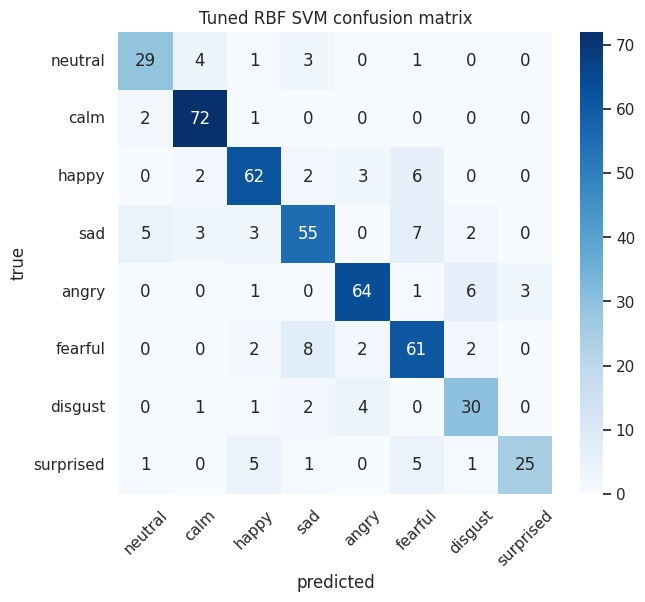

In [9]:
cm = confusion_matrix(y_test, bestPred, labels=labels)
labelNames = [emotionNames[i] for i in labels]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labelNames,
    yticklabels=labelNames,
    ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Tuned RBF SVM confusion matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 8. Notes for the Report

What this says about SVMs here:

- MiniLearn linear SVM works, but it is a basic gradient-descent implementation and trails sklearn's optimized linear SVM.
- Linear SVM is in the same broad range as earlier linear models, which makes sense because the decision boundary is still linear.
- RBF SVM is much stronger on this feature table, which suggests the emotion classes are separated by nonlinear relationships between audio summaries.
- Polynomial SVM is not automatically better just because it is nonlinear. On this run it is weaker than RBF.

Implementation note:

- MiniLearn only implements linear SVM. Kernel SVM from scratch would be a separate, much larger implementation, so sklearn is the right place for the RBF/poly comparisons.